LOAD DATA

In [3]:
import pandas as pd

In [4]:
# Load dataset
df = pd.read_csv('Native_Load_2025.csv')

In [5]:
# Preview
df.head()

,Hour Ending,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT
0,01/01/2025 01:00,"10,538.55","1,545.47","7,090.62","1,388.57","11,964.87","3,012.77","6,447.30","1,235.72","43,223.86"
1,01/01/2025 02:00,"10,477.91","1,553.99","7,040.46","1,390.39","12,064.92","2,962.80","6,382.65","1,249.40","43,122.53"
2,01/01/2025 03:00,"10,363.02","1,534.58","7,028.74","1,390.63","12,040.26","2,981.43","6,320.12","1,259.73","42,918.51"
3,01/01/2025 04:00,"10,259.98","1,548.08","6,992.73","1,402.42","12,055.42","2,970.76","6,277.13","1,274.24","42,780.78"
4,01/01/2025 05:00,"10,332.69","1,585.77","7,026.07","1,425.90","12,307.61","2,975.63","6,298.52","1,301.04","43,253.23"


CLEAN DATA

In [6]:
df.columns

Index(['Hour Ending', 'COAST', 'EAST', 'FWEST', 'NORTH', 'NCENT', 'SOUTH',
       'SCENT', 'WEST', 'ERCOT'],
      dtype='object')

Identify and Rename

In [7]:
df = df.rename(columns={'Hour Ending': 'Datetime'})

Fix datetime

In [8]:
df['Datetime'] = df['Datetime'].astype(str).str.replace('DST', '').str.strip()

In [9]:
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')

In [10]:
df = df.dropna(subset=['Datetime'])
df = df.sort_values('Datetime')
df = df.drop_duplicates(subset=['Datetime'])
df = df.reset_index(drop=True)

VERIFY

In [11]:
print(df['Datetime'].head())
print(df['Datetime'].isnull().sum())

0   2025-01-01 01:00:00
1   2025-01-01 02:00:00
2   2025-01-01 03:00:00
3   2025-01-01 04:00:00
4   2025-01-01 05:00:00
Name: Datetime, dtype: datetime64[ns]
0


Fix numeric columns

In [12]:
# Convert load columns from text to numeric
load_cols = ['COAST','EAST','FWEST','NORTH','NCENT','SOUTH','SCENT','WEST','ERCOT']
for col in load_cols:
    df[col] = (df[col].astype(str).str.replace(',', '', regex=False).str.strip())
    df[col] = pd.to_numeric(df[col], errors='coerce')

Clean dataset

In [13]:
# Remove bad numeric rows
df = df.dropna(subset=['ERCOT'])
# Sort again
df = df.sort_values('Datetime').reset_index(drop=True)
# Check data types
df.dtypes

Datetime    datetime64[ns]
COAST              float64
EAST               float64
FWEST              float64
NORTH              float64
NCENT              float64
SOUTH              float64
SCENT              float64
WEST               float64
ERCOT              float64
dtype: object

EXPLORATORY ANALYSIS

Load over time

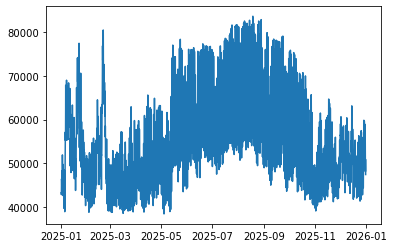

In [16]:
import matplotlib.pyplot as plt
plt.plot(df['Datetime'], df['ERCOT'])

Daily load profile

<AxesSubplot:xlabel='Hour'>

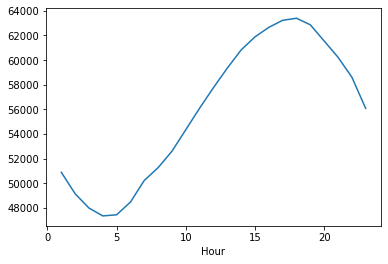

In [17]:
df['Hour'] = df['Datetime'].dt.hour
df.groupby('Hour')['ERCOT'].mean().plot()

Load ramp (advanced insight)

In [18]:
df['Load_Change'] = df['ERCOT'].diff()

MARKET DATA (PRICE)

Load price data

CREATE REALISTIC PRICE MODEL

In [21]:
import numpy as np

# Normalize load (0 to 1)
load_norm = (df['ERCOT'] - df['ERCOT'].min()) / (df['ERCOT'].max() - df['ERCOT'].min())

# Create realistic price curve (nonlinear)
df['Price'] = 20 + 100 * (load_norm**2)

# Add randomness (market volatility)
df['Price'] += np.random.normal(0, 5, len(df))

VISUALIZE LOAD vs PRICE

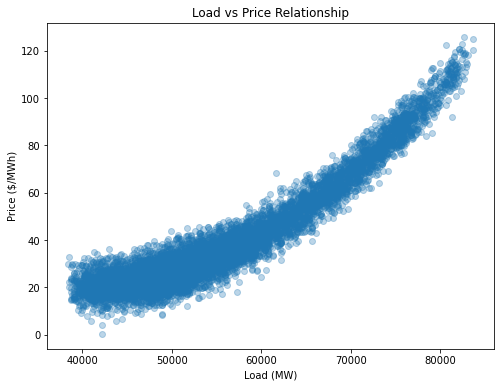

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df['ERCOT'], df['Price'], alpha=0.3)
plt.xlabel('Load (MW)')
plt.ylabel('Price ($/MWh)')
plt.title('Load vs Price Relationship')
plt.show()

BUILD STRESS MODEL (KEY DIFFERENTIATOR)

In [23]:
load_th = df['ERCOT'].quantile(0.9)
price_th = df['Price'].quantile(0.9)

df['Stress'] = (df['ERCOT'] > load_th) & (df['Price'] > price_th)

VISUALIZE STRESS

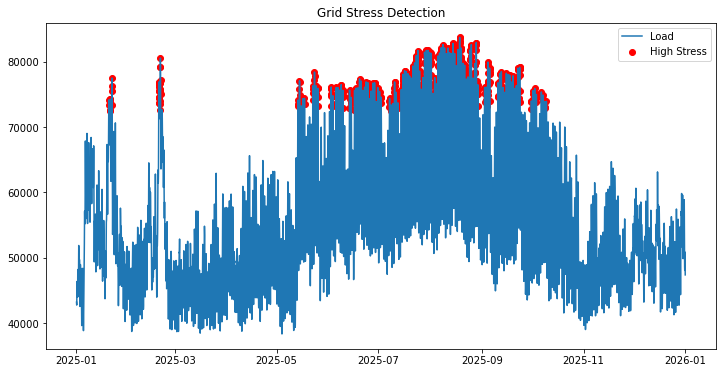

In [24]:
plt.figure(figsize=(12,6))
plt.plot(df['Datetime'], df['ERCOT'], label='Load')

plt.scatter(df[df['Stress']]['Datetime'],
            df[df['Stress']]['ERCOT'],
            color='red', label='High Stress')

plt.legend()
plt.title('Grid Stress Detection')
plt.show()

FORECASTING

PREP YOUR DATA

In [34]:
# Features (X) and target (y)
X = df[['ERCOT']]
y = df['Price']

SPLIT DATA (IMPORTANT)

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

BUILD MODEL (LINEAR REGRESSION)

In [36]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

MAKE PREDICTIONS

In [37]:
y_pred = model.predict(X_test)

VISUALIZE PREDICTION (VERY IMPORTANT)

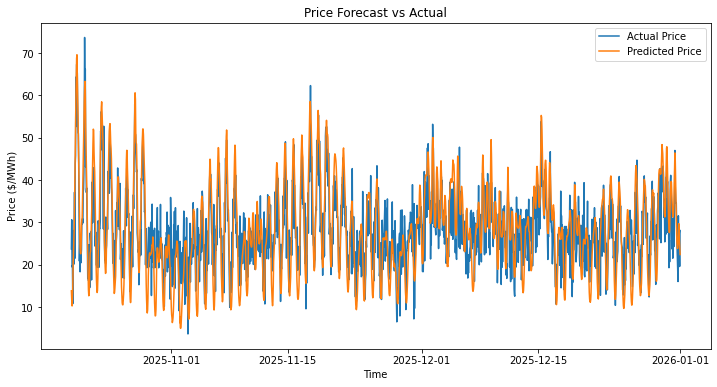

In [38]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(df['Datetime'].iloc[-len(y_test):], y_test, label='Actual Price')
plt.plot(df['Datetime'].iloc[-len(y_test):], y_pred, label='Predicted Price')
plt.legend()
plt.title('Price Forecast vs Actual')
plt.xlabel('Time')
plt.ylabel('Price ($/MWh)')
plt.show()

EVALUATE MODEL

In [39]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 5.551991061980431


Classification Model (Stress Detection using ML)

DEFINE TARGET (LABEL)

In [41]:
load_th = df['ERCOT'].quantile(0.9)
price_th = df['Price'].quantile(0.9)

df['Stress'] = ((df['ERCOT'] > load_th) & (df['Price'] > price_th)).astype(int)

CREATE FEATURES

In [60]:
df['Hour'] = df['Datetime'].dt.hour
df['Month'] = df['Datetime'].dt.month

X = df[['ERCOT', 'Price', 'Hour', 'Month']]
y = df['Stress']

TRAIN/TEST SPLIT

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

TRAIN MODEL (LOGISTIC REGRESSION)

In [62]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

PREDICT

In [63]:
y_pred = model.predict(X_test)

EVALUATE MODEL

In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1654
           1       0.44      0.88      0.59        25

    accuracy                           0.98      1679
   macro avg       0.72      0.93      0.79      1679
weighted avg       0.99      0.98      0.98      1679



VISUALIZE RESULTS

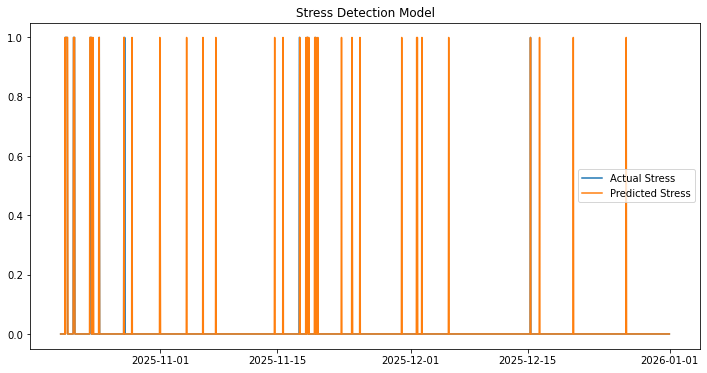

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df['Datetime'].iloc[-len(y_test):], y_test, label='Actual Stress')
plt.plot(df['Datetime'].iloc[-len(y_test):], y_pred, label='Predicted Stress')

plt.legend()
plt.title('Stress Detection Model')
plt.show()

In [66]:
print(df['Stress'].value_counts())

0    6419
1    1976
Name: Stress, dtype: int64


In [67]:
load_th = df['ERCOT'].quantile(0.9)
price_th = df['Price'].quantile(0.9)

In [68]:
load_th = df['ERCOT'].quantile(0.75)
price_th = df['Price'].quantile(0.75)

In [69]:
df['Stress'] = ((df['ERCOT'] > load_th) & (df['Price'] > price_th)).astype(int)

In [70]:
print(df['Stress'].value_counts())

0    6419
1    1976
Name: Stress, dtype: int64


In [71]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [76]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:,1]

In [77]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1654
           1       1.00      1.00      1.00        25

    accuracy                           1.00      1679
   macro avg       1.00      1.00      1.00      1679
weighted avg       1.00      1.00      1.00      1679



In [78]:
proba = model.predict_proba(X_test)[:,1]

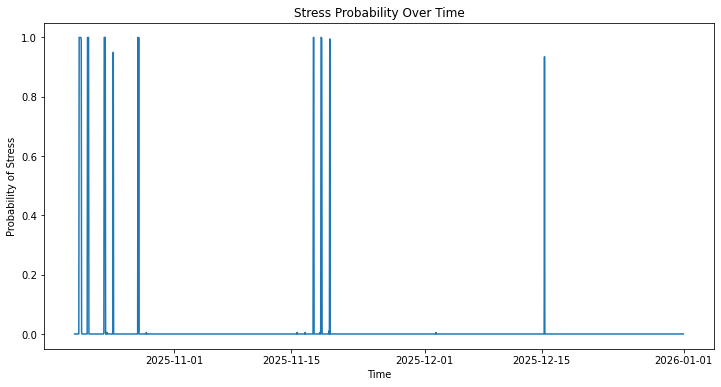

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Datetime'].iloc[-len(proba):], proba)
plt.title('Stress Probability Over Time')
plt.xlabel('Time')
plt.ylabel('Probability of Stress')
plt.show()

In [80]:
df_test = df.iloc[-len(proba):].copy()
df_test['Proba'] = proba

# Smooth probabilities
df_test['Proba_Smooth'] = df_test['Proba'].rolling(window=24).mean()

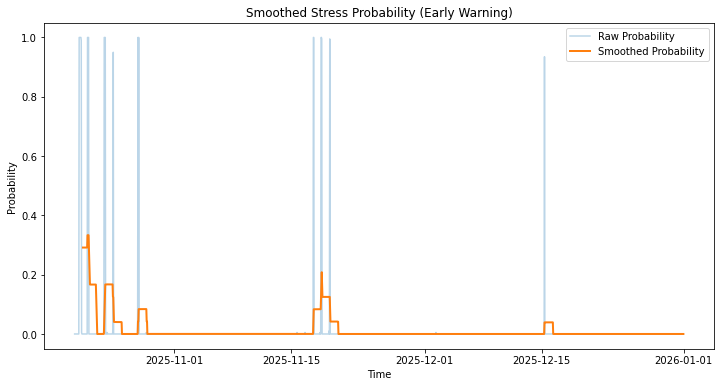

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df_test['Datetime'], df_test['Proba'], alpha=0.3, label='Raw Probability')
plt.plot(df_test['Datetime'], df_test['Proba_Smooth'], linewidth=2, label='Smoothed Probability')

plt.legend()
plt.title('Smoothed Stress Probability (Early Warning)')
plt.xlabel('Time')
plt.ylabel('Probability')
plt.show()

In [82]:
df_test['Alert'] = df_test['Proba_Smooth'] > 0.1

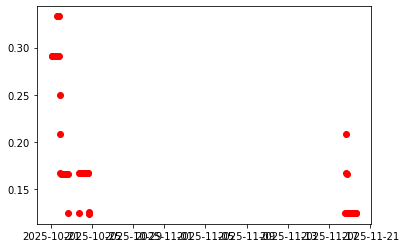

In [83]:
plt.scatter(df_test[df_test['Alert']]['Datetime'],
            df_test[df_test['Alert']]['Proba_Smooth'],
            color='red', label='Alert')